# Introduction into Data Science - Assignment Part II

This is the second part of the assignment in IDS 2023/2024.

This part of the assignment consists of five questions — each of these questions is contained in a separate Jupyter notebook:
- [Question 1: Data Preprocessing](Q1_Preprocessing_Visualization.ipynb)
- [Question 2: Association Rules](Q2_Frequent_Itemsets_Association_Rules.ipynb)
- [Question 3: Process Mining](Q3_Process_Mining.ipynb)
- [Question 4: Text Mining](Q4_Text_Mining.ipynb)
- [Question 5: Big Data](Q5_Big_Data.ipynb)

Additional required files are in two folders.
- [datasets](datasets/)
- [scripts](scripts/)

Please use the provided notebook to work on the questions. When you are done, upload your version of each of the notebooks to Moodle. Your submission will, therefore, consist of five jupyter notebook and _no_ additional file. Any additionally provided files will not be considered in grading.
Enter your commented Python code and answers in the corresponding cells. Make sure to answer all questions in a clear and explicit manner and discuss your outputs. _Please do not change the general structure of this notebook_. You can, however, add additional markdown or code cells if necessary. Please **DO NOT CLEAR THE OUTPUT** of the notebook you are submitting! Additionally, please ensure that the code in the notebook runs if placed in the same folder as all of the provided files, delivering the same outputs as the ones you submit in the notebook. This includes being runnable in the bundled conda environment.

*Please make sure to include the names and matriculation numbers of all group members in the provided slots in each of the notebooks.* If a name or a student id is missing, the student will not receive any points.

Hint 1: **Plan your time wisely.** A few parts of this assignment may take some time to run. It might be necessary to consider time management when you plan your group work. Also, do not attempt to upload your assignment at the last minute before the deadline. This often does not work, and you will miss the deadline. Late submissions will not be considered.

Hint 2: RWTHMoodle allows multiple submissions, with every new submission overwriting the previous one. **Partial submissions are possible and encouraged.** This might be helpful in case of technical issues with RWTHMoodle, which may occur close to the deadline.

Hint 3: As a technical note. Some IDEs such as DataSpell may automatically strip jupyter notebook cell metadata. If you are able, please re-add it from the source notebooks before submission. This is necessary for our grading.

Enter your group number and members with matriculation numbers below.

In [1]:
GROUP_NO = 47 # group number
GROUP_MEMBERS = {
    460101: "Feiyu Wang", # mat. no. : name,
    460790: "Malte Schörken",
    461277: "Chenmingxuan Feng",
}

---

In [2]:
# required imports
# do not edit!

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Question 1: Preprocessing and Visualization (19 Points)

**About the Data: Heart Disease**

In this task, our data (`q1_heart_disease.csv`) contains records related to the diagnosis of heart disease in patients. It includes various clinical and non-clinical attributes used to determine the presence or absence of heart disease. Columns cover aspects like patient demographics, vital signs, symptoms, and potential risk factors associated with heart conditions. See below a short description for each column.

| Column         | Description                                                                                                                       |
|----------------|-----------------------------------------------------------------------------------------------------------------------------------|
| Age            | The age of the patient in years.                                                                                                  |
| Sex            | The sex of the patient.                                                                                                           |
| ChestPainType  | The type of chest pain (TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomnic).                       |
| RestingBP      | The resting blood pressure in millimeter of mercury [mmHg].                                                                       |
| Cholesterol    | The cholesterol of the blood serum in milligrams per deciliter (mg/dl).                                                           |
| FastingBS      | 1 if the blood sugar while fasting is above 120 mg/dl, 0 otherwise.                                                               |
| RestingECG     | Results of the electrocardiogram when resting.                                                                                    |
| MaxHR          | The maximum heart rate achieved while exercising.                                                                                 |
| ExerciseAngina | If an Angina (pressure on chest) is inducible by exercising.                                                                      |
| Oldpeak        | Numerical measure of the depression of the ST segment of electrocardiogram induced by exercise relative to rest.                  |
| ST_Slope       | The slope of the peak exercise ST segment, where 0 corresponds to downsloping; 1 to a flat level, and 2 corresponds to upsloping. |
| HeartDisease   | Heart disease being present or not.                                                                                               |

## Part I: Preprocessing (11 pts)

### a)
First things first. Import the file **q1_heart_disease.csv** and save it into a dataframe named `heart_df`. Visualize the dataframe by showing the first five lines. 


In [3]:
# Import and visualization.
# YOUR CODE HERE
heart_df = pd.read_csv('datasets/q1_heart_disease.csv')
print(heart_df.head())

    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0  40.0   M           ATA      140.0        289.0        0.0     Normal   
1  49.0   F           NAP      160.0        180.0        0.0     Normal   
2  37.0   M           ATA      130.0        283.0        0.0         ST   
3  48.0   F           ASY      138.0        214.0        0.0     Normal   
4  54.0   M           NAP      150.0        195.0        0.0     Normal   

   MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0  172.0              N      0.0       Up           0.0  
1  156.0              N      1.0     Flat           1.0  
2   98.0              N      0.0       Up           0.0  
3  108.0              Y      1.5     Flat           1.0  
4  122.0              N      0.0       Up           0.0  


### b) 
i. Check the data types. Are there any data type problems (e.g., numerical columns having a non-numerical data type)?

In [4]:
# Visualizing data types
# YOUR CODE HERE
print(heart_df.dtypes)
# It doesn't appear that there are any problems

Age               float64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS         float64
RestingECG         object
MaxHR             float64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease      float64
dtype: object


ii. Fix problems, if there are any data type problems. Further, improve categorical columns by setting them to the categorical type and translate boolean columns to boolean values.

In [5]:
# Fixing problems, if necessary
# YOUR CODE HERE


In [6]:
# Set categorical columns to categorial type.
# YOUR CODE HERE
heart_df['Sex'] = heart_df['Sex'].astype('category')
heart_df['ChestPainType'] = heart_df['ChestPainType'].astype('category')
heart_df['RestingECG'] = heart_df['RestingECG'].astype('category')
heart_df['ST_Slope'] = heart_df['ST_Slope'].astype('category')

In [7]:
# Translate boolean columns to boolean type
# YOUR CODE HERE
heart_df['ExerciseAngina'] = heart_df['ExerciseAngina'].map({'Y': 1, 'N': 0}).astype(bool)
heart_df['HeartDisease'] = heart_df['HeartDisease'].astype(bool)
heart_df['FastingBS'] = heart_df['FastingBS'].astype(bool)

In [8]:
# Checking again by visualizing data types
# YOUR CODE HERE
print(heart_df.dtypes)
print(heart_df.head())

Age                float64
Sex               category
ChestPainType     category
RestingBP          float64
Cholesterol        float64
FastingBS             bool
RestingECG        category
MaxHR              float64
ExerciseAngina        bool
Oldpeak            float64
ST_Slope          category
HeartDisease          bool
dtype: object
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0  40.0   M           ATA      140.0        289.0      False     Normal   
1  49.0   F           NAP      160.0        180.0      False     Normal   
2  37.0   M           ATA      130.0        283.0      False         ST   
3  48.0   F           ASY      138.0        214.0      False     Normal   
4  54.0   M           NAP      150.0        195.0      False     Normal   

   MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0  172.0           False      0.0       Up         False  
1  156.0           False      1.0     Flat          True  
2   98.0           False      0.0 

### c)
i. In this subtask, we start with a first evaluation of our data by checking the plausibility of some entries. To make sure that we do not have a clash between intended NaN values and existing NaN values in the dataset, we first remove all NaN values. Report the number of rows containing a NaN value.

In [9]:
# YOUR CODE HERE
heart_df_cleaned = heart_df.dropna()

print('Rows containing NaN:', len(heart_df[heart_df.isnull().any(axis=1)]))
print(heart_df[heart_df.isnull().any(axis=1)])

Rows containing NaN: 2
      Age  Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
422   NaN  NaN           NAP      110.0        213.0       True     Normal   
516  62.0    F           NaN        NaN          NaN       True        NaN   

     MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
422  141.0            True      2.0       Up          True  
516    NaN            True      NaN      NaN          True  


ii. To check plausibility, create boxplots for all numerical features. Reason which features have invalid or missing values. Show and report such outliers. 

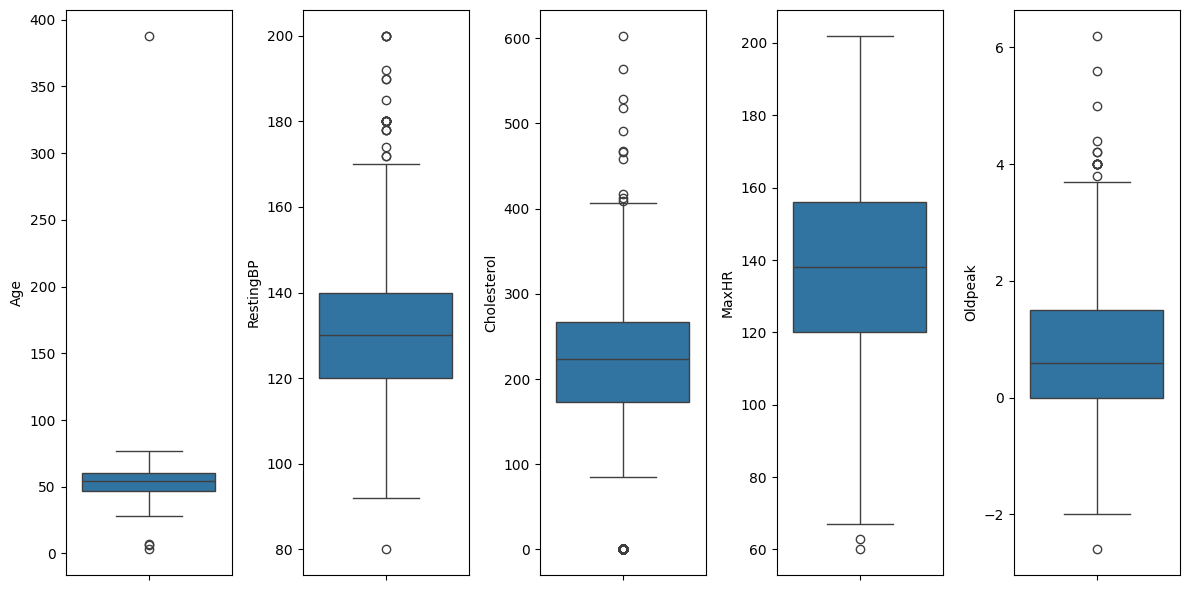

In [10]:
# Creating the boxplot and calculating outliers
# YOUR CODE HERE
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12,6))
for i, col in enumerate(heart_df_cleaned.select_dtypes(include=['float64']).columns):
    sns.boxplot(y=heart_df_cleaned[col], ax=axes[i%5])
plt.tight_layout()
plt.show()

_Note: There may be more cells than what you may need for viewing and reporting the entries properly and nicely._

In [11]:
# Potential viewing and reporting of outlier entries
# YOUR CODE HERE

# I'm explicitly considering unrealistic outliers since actual outliers are important and shouldn't be imputed!

# Unrealistic age 388:
age_too_high = heart_df_cleaned[heart_df_cleaned['Age'] > 120]
print(age_too_high)

       Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
597  388.0   M           ASY      160.0        256.0       True         ST   

     MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
597  136.0           False      0.2       Up         False  


In [12]:
# Potential viewing and reporting of outlier entries
# YOUR CODE HERE

# Impossible Oldpeak value:
oldpeak_negative = heart_df_cleaned[heart_df_cleaned['Oldpeak'] < 0]
print(oldpeak_negative)

      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
323  63.0   M           ASY      100.0          0.0       True     Normal   
326  46.0   M           ASY      100.0          0.0       True         ST   
327  42.0   M           ASY      105.0          0.0       True     Normal   
328  45.0   M           NAP      110.0          0.0      False     Normal   
333  56.0   M           ASY      115.0          0.0       True         ST   
334  38.0   M           NAP      100.0          0.0      False     Normal   
336  51.0   M           ASY      130.0          0.0       True     Normal   
337  62.0   M            TA      120.0          0.0       True        LVH   
355  56.0   M           ASY      120.0          0.0      False         ST   
410  62.0   M           ASY      115.0          0.0       True     Normal   
416  56.0   M           NAP      125.0          0.0       True     Normal   
425  66.0   M           NAP      120.0          0.0      False         ST   

In [13]:
# Potential viewing and reporting of outlier entries
# YOUR CODE HERE
# Impossible Cholesterol value:
cholesterol_zero = heart_df_cleaned[heart_df_cleaned['Cholesterol'] <= 0]
print(cholesterol_zero)

      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
295  65.0   M           ASY      115.0          0.0      False     Normal   
296  32.0   M            TA       95.0          0.0       True     Normal   
297  61.0   M           ASY      105.0          0.0       True     Normal   
298  50.0   M           ASY      145.0          0.0       True     Normal   
299  57.0   M           ASY      110.0          0.0       True         ST   
..    ...  ..           ...        ...          ...        ...        ...   
518  43.0   M           ASY      122.0          0.0      False     Normal   
519  63.0   M           NAP      130.0          0.0       True         ST   
522  48.0   M           NAP      102.0          0.0       True         ST   
539  56.0   M           ASY      130.0          0.0      False        LVH   
540  62.0   M           NAP      133.0          0.0       True         ST   

     MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
295   93.0    

In [14]:
# Potential viewing and reporting of outlier entries
# YOUR CODE HERE

iii. Decide and briefly reason which entries can be kept such that some values can be imputed later and which entries have to be deleted. Apply the preprocessing by either deleting entries or by replacing values that should be imputed by setting their value to NaN respectively. Report for both processings how many entries are effected.

__Student Answer:__ I don't see any problem with imputing all the values. Therefore for the deleting 0 entries are effected and for the replacing 186 entries are effected.

In [15]:
# Potential removing of outliers, reporting their number, and showing of the resulting dataframe
# YOUR CODE HERE


In [16]:
# Potential replacing of values with NaN, reporting their number, and showing of the resulting dataframe
# YOUR CODE HERE
heart_df_impute = heart_df_cleaned.copy()
# replace 172 times Cholesterol = 0
heart_df_impute['Cholesterol'] = heart_df_impute['Cholesterol'].replace(0, float('nan'))
# replace 1 time Age = 388
heart_df_impute['Age'] = np.where(heart_df_impute['Age'] > 120, np.nan, heart_df_impute['Age'])
# replace 13 times Oldpeak < 0
heart_df_impute['Oldpeak'] = np.where(heart_df_impute['Oldpeak'] < 0, np.nan, heart_df_impute['Oldpeak'])

print(heart_df_impute.head())
print(len(cholesterol_zero), "entries replaced in Cholesterol")
print(len(oldpeak_negative), "entries replaced in Oldpeak")
print(len(age_too_high), "entries replaced in Age")
print(len(cholesterol_zero)+len(oldpeak_negative)+len(age_too_high),"total entries replaced.")

    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0  40.0   M           ATA      140.0        289.0      False     Normal   
1  49.0   F           NAP      160.0        180.0      False     Normal   
2  37.0   M           ATA      130.0        283.0      False         ST   
3  48.0   F           ASY      138.0        214.0      False     Normal   
4  54.0   M           NAP      150.0        195.0      False     Normal   

   MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0  172.0           False      0.0       Up         False  
1  156.0           False      1.0     Flat          True  
2   98.0           False      0.0       Up         False  
3  108.0            True      1.5     Flat          True  
4  122.0           False      0.0       Up         False  
172 entries replaced in Cholesterol
13 entries replaced in Oldpeak
1 entries replaced in Age
186 total entries replaced.


iv. To give yourself a better insight, plot the resulting dataframe again using boxplots.

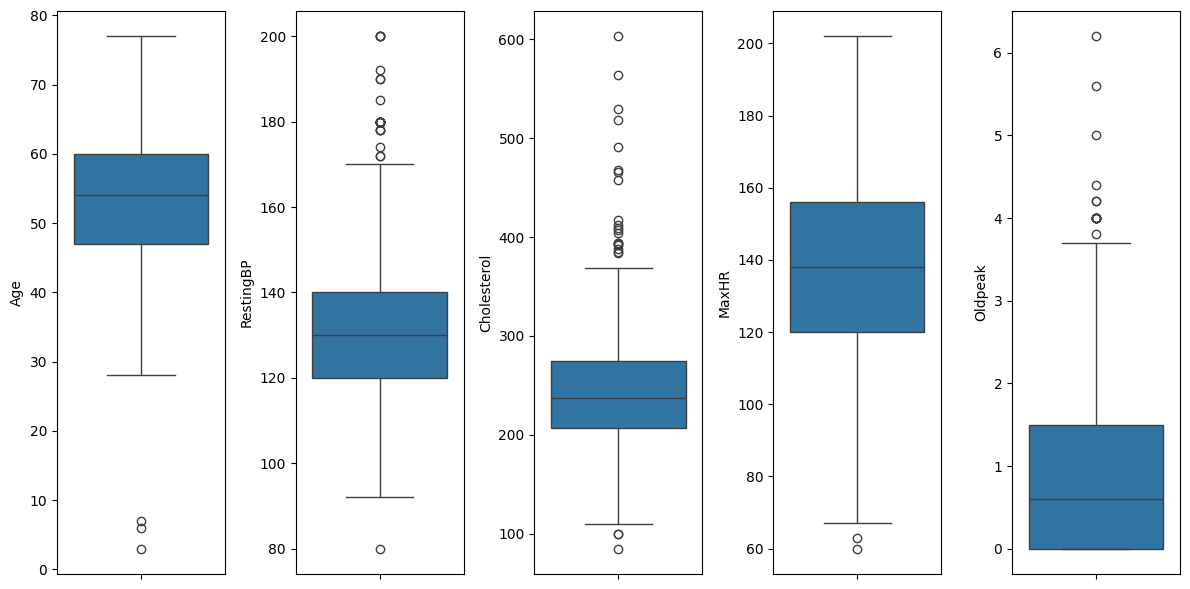

In [17]:
# Creating a boxplot
# YOUR CODE HERE
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12,6))
for i, col in enumerate(heart_df_impute.select_dtypes(include=['float64']).columns):
    sns.boxplot(y=heart_df_impute[col], ax=axes[i%5])
plt.tight_layout()
plt.show()

### d)
In this task, we apply one-hot encoding for all categorical and all boolean features. This is used later for visualization. Afterwards, show the resulting dataframe.

In [18]:
# Replacing categorical and boolean features with one-hot encoded columns
# YOUR CODE HERE

# I am using One-Hot-Encoding. Pandas Dummies function would work too.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

categorical_columns = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']
preprocessor = make_column_transformer(
    (OneHotEncoder(), categorical_columns),
    remainder='passthrough'
)
heart_df_encoded = preprocessor.fit_transform(heart_df_impute)
heart_df_encoded = pd.DataFrame(heart_df_encoded, columns=preprocessor.get_feature_names_out())
print(heart_df_encoded.head())

   onehotencoder__Sex_F  onehotencoder__Sex_M  \
0                   0.0                   1.0   
1                   1.0                   0.0   
2                   0.0                   1.0   
3                   1.0                   0.0   
4                   0.0                   1.0   

   onehotencoder__ChestPainType_ASY  onehotencoder__ChestPainType_ATA  \
0                               0.0                               1.0   
1                               0.0                               0.0   
2                               0.0                               1.0   
3                               1.0                               0.0   
4                               0.0                               0.0   

   onehotencoder__ChestPainType_NAP  onehotencoder__ChestPainType_TA  \
0                               0.0                              0.0   
1                               1.0                              0.0   
2                               0.0               

### e)
i. In this task, we want to impute missing values based on their k-nearest neighbor. Therefore, as a first step, create a reduced dataframe that contains the column(s) with missing values and with columns that correlate with the missing value. To decide which features (weakly) correlate, consider the correlation matrix in the figure below that is taken from literature (Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10417090/). Consider all features that have an absolute value for the correlation coefficient of at least 0.1 with the missing value.

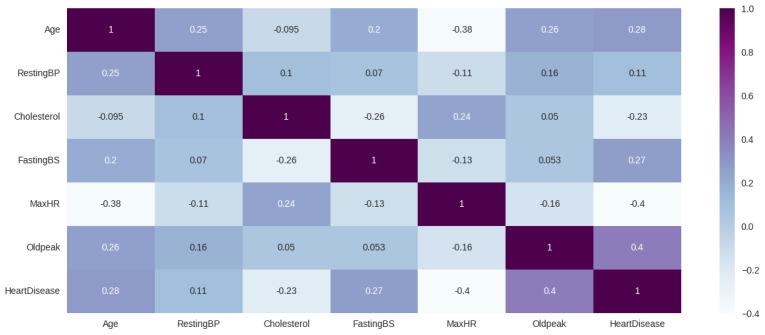

Figure 1: Correlation matrix between different features from Literature. (Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10417090/)

In [19]:
# Creating a dataframe with the values to be imputed and the correlating columns
# YOUR CODE HERE
heart_df_age = heart_df_encoded.drop('remainder__Cholesterol', axis=1)
heart_df_cholesterol = heart_df_encoded.drop(columns = ['remainder__Oldpeak', 'remainder__Age'])
heart_df_oldpeak = heart_df_encoded.drop(columns = ['onehotencoder__FastingBS_False', 'onehotencoder__FastingBS_True',
                                                    'remainder__Cholesterol'])

heart_df_oldpeak

,onehotencoder__Sex_F,onehotencoder__Sex_M,onehotencoder__ChestPainType_ASY,onehotencoder__ChestPainType_ATA,onehotencoder__ChestPainType_NAP,onehotencoder__ChestPainType_TA,onehotencoder__RestingECG_LVH,onehotencoder__RestingECG_Normal,onehotencoder__RestingECG_ST,onehotencoder__ExerciseAngina_False,onehotencoder__ExerciseAngina_True,onehotencoder__ST_Slope_Down,onehotencoder__ST_Slope_Flat,onehotencoder__ST_Slope_Up,onehotencoder__HeartDisease_False,onehotencoder__HeartDisease_True,remainder__Age,remainder__RestingBP,remainder__MaxHR,remainder__Oldpeak
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,40.0,140.0,172.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,49.0,160.0,156.0,1.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,37.0,130.0,98.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,48.0,138.0,108.0,1.5
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,54.0,150.0,122.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,45.0,110.0,132.0,1.2
917,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,68.0,144.0,141.0,3.4
918,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,57.0,130.0,115.0,1.2
919,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,57.0,130.0,174.0,0.0


__Student Answer:__ _your answer goes here_

ii. Next, use k-nearest neighbor imputation with $k = 5$. Impute the missing values. Update the dataframe `heart_df`.

In [20]:
# Applying k-nearest neighbor imputation
# YOUR CODE HERE
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
heart_df_age = pd.DataFrame(knn_imputer.fit_transform(heart_df_age), columns = heart_df_age.columns)
heart_df_cholesterol = pd.DataFrame(knn_imputer.fit_transform(heart_df_cholesterol), columns = heart_df_cholesterol.columns)
heart_df_oldpeak = pd.DataFrame(knn_imputer.fit_transform(heart_df_oldpeak), columns = heart_df_oldpeak.columns)

In [21]:
# Updating the imputed column(s)
# YOUR CODE HERE
heart_df_clean = heart_df_impute.copy()
nan_count_per_column = heart_df_clean.isna().sum()
print("\nNumber of NaN values per column before imputation:")
print(nan_count_per_column)

heart_df_clean['Age'] = heart_df_age['remainder__Age'].values
heart_df_clean['Cholesterol'] = heart_df_cholesterol['remainder__Cholesterol'].values
heart_df_clean['Oldpeak'] = heart_df_oldpeak['remainder__Oldpeak'].values

print("\n NaN-Values in cleaned df:", heart_df_clean.isna().any().any())
nan_count_per_column = heart_df_clean.isna().sum()
print("\nNumber of NaN values per column after imputation:")
print(nan_count_per_column)


Number of NaN values per column before imputation:
Age                 1
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak            13
ST_Slope            0
HeartDisease        0
dtype: int64

 NaN-Values in cleaned df: False

Number of NaN values per column after imputation:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Part II: Advanced Visualization (8 pts)

In this question, we continue using the preprocessed data from Part I.

### a)
In this task, visualize the relation by plotting each pair of numerical features. Visualize the instances in the pairplots of those individuals that have and that do not have heart disease.

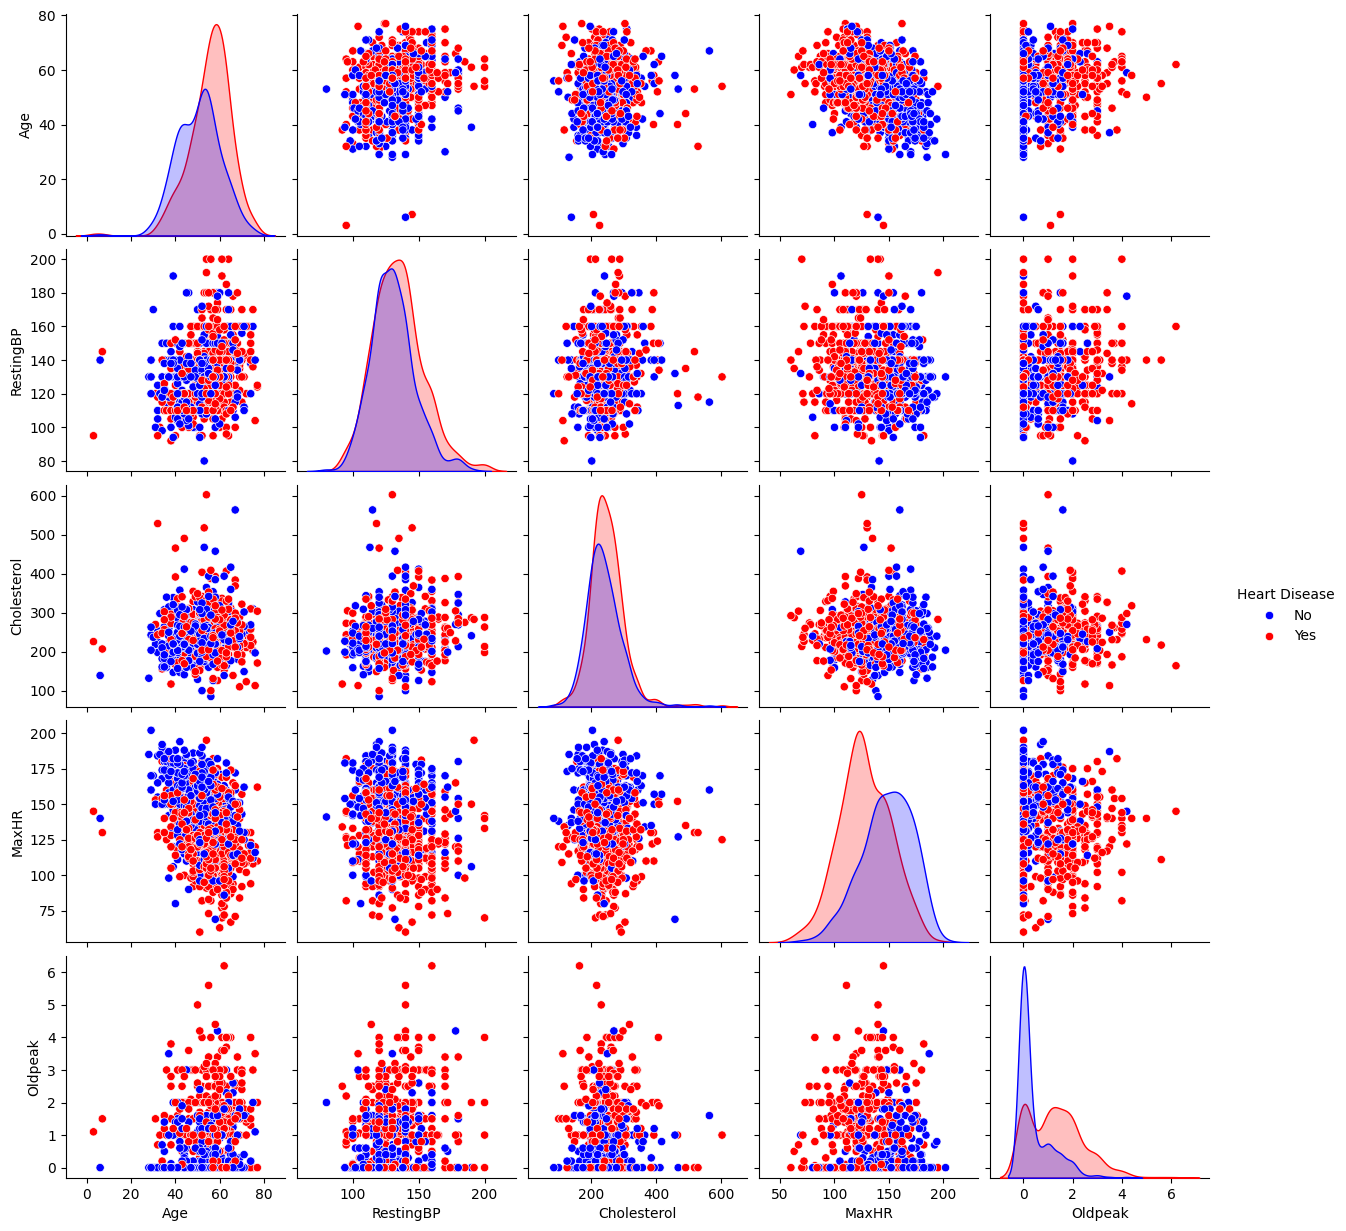

In [22]:
# Visualizing the relation between the numerical values using a pairplot, where the entries are classified by whether a heart disease is present 
# YOUR CODE HERE

numerical_df = heart_df_clean.select_dtypes(include=['float64'])
numerical_df['HeartDisease'] = heart_df_clean['HeartDisease'].astype('category')
pairplot = sns.pairplot(numerical_df, hue='HeartDisease', palette={0: 'blue', 1: 'red'})
pairplot._legend.set_title("Heart Disease")
for text, label in zip(pairplot._legend.texts, ["No", "Yes"]):
    text.set_text(label)
plt.show()

### b)
i. Having the pairplot, we are interested in more details on the relation between the age of a patient and maximum heart rate. Therefore, create plot that shows the regression line between both features.

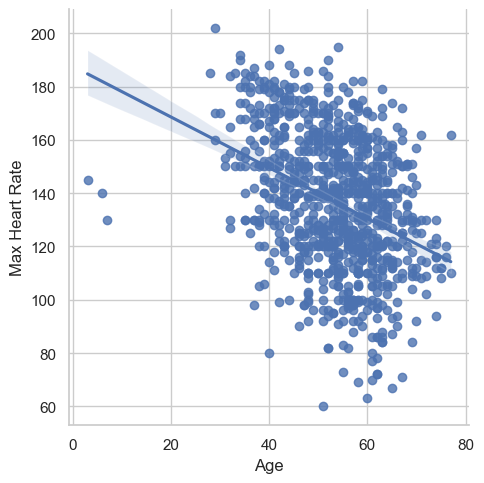

In [23]:
# Plotting age and maximum heart rate with regression line
# YOUR CODE HERE

sns.set(style="whitegrid")

regression_plot = sns.lmplot(x='Age', y='MaxHR', data=heart_df_clean)
regression_plot.set_axis_labels("Age", "Max Heart Rate")
plt.show()

ii. Given our evaluation from task b-i), we are not sure if Simpson's Paradox occurs or not. Give some short reasoning, and if needed, do some experiment to check whether Simpson's Paradox occurs.

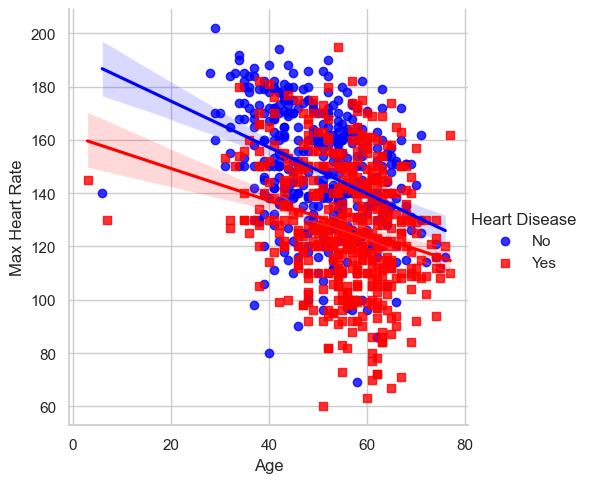

In [24]:
# Potential code for Simpson's Paradox testing
# YOUR CODE HERE

sns.set(style="whitegrid")

regression_plot = sns.lmplot(x='Age', y='MaxHR', data=heart_df_clean, hue='HeartDisease', palette={0: 'blue', 1: 'red'}, markers=['o', 's'])

regression_plot.set_axis_labels("Age", "Max Heart Rate")
regression_plot._legend.set_title("Heart Disease")
legend_labels = ["No", "Yes"]
for t, l in zip(regression_plot._legend.texts, legend_labels):
    t.set_text(l)
plt.show()


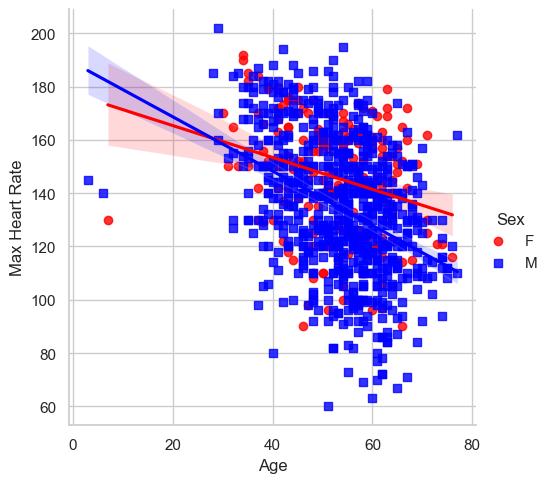

In [25]:
# Potential code for Simpson's Paradox testing
# YOUR CODE HERE

sns.set(style="whitegrid")

regression_plot = sns.lmplot(x='Age', y='MaxHR', data=heart_df_clean, hue='Sex', palette={'M': 'blue', 'F': 'red'}, markers=['o', 's'])

regression_plot.set_axis_labels("Age", "Max Heart Rate")
regression_plot._legend.set_title("Sex")
legend_labels = ["F", "M"]
for t, l in zip(regression_plot._legend.texts, legend_labels):
    t.set_text(l)
plt.show()

__Student Answer:__ It was not clearly stated which subgroups to consider when checking for Simpsons paradox. We decided for Heart Disease and Sex. It appears that the same trend is visible in all considered subgroups therefore Simpson's paradox does not occur.

### c)
In this task, we want to obtain a deeper understanding of the characteristics of each state of the former categorical or boolean features. Therefore, we create a heatmap that can be used to get a first impression of which value of which feature correlates with each other feature. 

i. Create a dataframe that contains as its columns the feature states and as its index all the column names of `heart_df`. Each entry is the sum of entries that have such a combination of features being true for the one-hot encoded features. For example, given the entries:
| ID | Feature1_True | Feature1_False | Feature2_StateA | Feature2_StateB | Feature2_StateC | Feature3_StateA | Feature3_StateB |
|----|---------------|----------------|-----------------|-----------------|-----------------|-----------------|-----------------|
| 1  | True          | False          | True            | False           | False           | True            | False           |
| 2  | True          | False          | False           | True            | False           | True            | False           |
| 3  | False         | True           | False           | True            | False           | True            | False           |

In this example, we would obtain the following entries as a result:

|                 | Feature1_True | Feature1_False | Feature2_StateA | Feature2_StateB | Feature2_StateC | Feature3_StateA | Feature3_StateB |
|-----------------|---------------|----------------|-----------------|-----------------|-----------------|-----------------|-----------------|
| Feature1_True   | 2             | 0              | 1               | 1               | 0               | 2               | 0               |
| Feature1_False  | 0             | 1              | 0               | 1               | 0               | 1               | 0               |
| Feature2_StateA | 1             | 0              | 1               | 0               | 0               | 1               | 0               |
| Feature2_StateB | 1             | 1              | 0               | 2               | 0               | 2               | 0               |
| Feature2_StateC | 0             | 0              | 0               | 0               | 0               | 0               | 0               |
| Feature3_StateA | 2             | 1              | 1               | 2               | 0               | 3               | 0               |
| Feature3_StateB | 0             | 0              | 0               | 0               | 0               | 0               | 0               |

In [26]:
# Creating the data for the heatmap.
# YOUR CODE HERE

tmp_heatmap_df = heart_df_encoded.drop(columns = ['remainder__Age', 'remainder__RestingBP', 'remainder__Cholesterol',
                                              'remainder__MaxHR', 'remainder__Oldpeak'])
heatmap_df = pd.DataFrame()
i = 0
for feature in tmp_heatmap_df.columns:
    df = pd.DataFrame(tmp_heatmap_df.groupby(feature).sum().iloc[1]) # here I am missing the feature itself in the df
    # I have to adjust for this by manually putting the row in the correct place
    df = pd.concat([df.iloc[:i], pd.DataFrame([tmp_heatmap_df[feature].sum()], columns=df.columns),
                    df.iloc[i:]]).reset_index(drop=False)
    heatmap_df[feature] = df[1].astype(int)
    i+=1

heatmap_df.set_index(tmp_heatmap_df.columns, inplace=True)
print(heatmap_df)

                                     onehotencoder__Sex_F  \
onehotencoder__Sex_F                                  194   
onehotencoder__Sex_M                                    0   
onehotencoder__ChestPainType_ASY                       70   
onehotencoder__ChestPainType_ATA                       61   
onehotencoder__ChestPainType_NAP                       53   
onehotencoder__ChestPainType_TA                        10   
onehotencoder__FastingBS_False                        167   
onehotencoder__FastingBS_True                          27   
onehotencoder__RestingECG_LVH                          47   
onehotencoder__RestingECG_Normal                      119   
onehotencoder__RestingECG_ST                           28   
onehotencoder__ExerciseAngina_False                   151   
onehotencoder__ExerciseAngina_True                     43   
onehotencoder__ST_Slope_Down                            7   
onehotencoder__ST_Slope_Flat                           76   
onehotencoder__ST_Slope_

ii. Next, create the heatmap based on the data from the last subtask. If necessary, improve readability of the visualization.

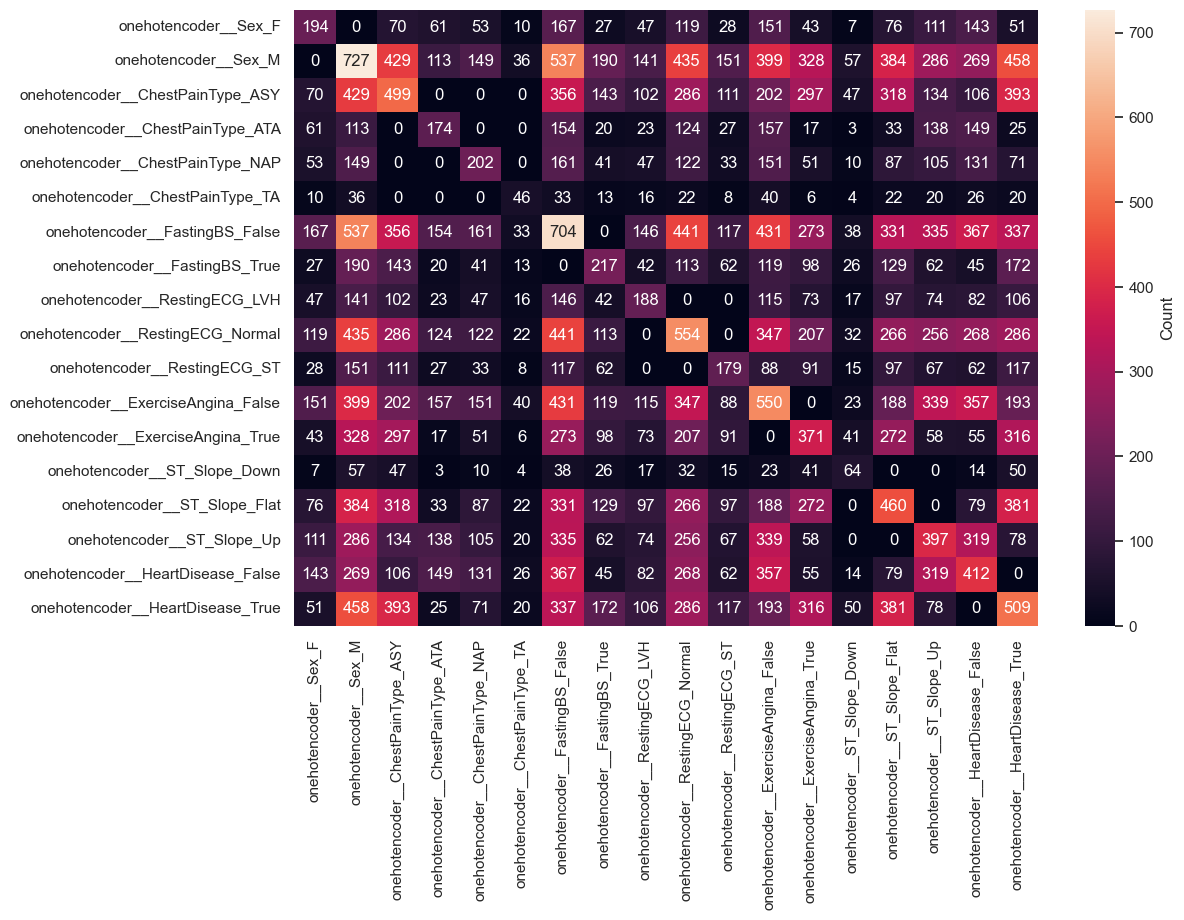

In [27]:
# Visualizing the obtained heatmap
# YOUR CODE HERE

plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(heatmap_df, annot=True, fmt='.0f', cbar_kws={'label': 'Count'})
plt.show()

Given the heatmap, briefly derive some insights towards the different values of a feature. I.e., you may choose a heart disease being present or not and argue about what correlates for the other features for each value.

__Student Answer:__ The following trends are being observed: 
- Males are way more likely to have a heart disease than female. (Male: 62%, Female: 26%)
- ChestPainType ASY is an indicator of heart disease: 79% of patients with this pain type have a heart disease.
- ChestPainType ATA is an indicator for no heart disease: Only 14% of patients with this pain type have a heart disease.
- FastingBS True is a strong indicator for a heart disease: 79%
- For RestingECG the only clear trend is that the type ST correlates to heart disease being True.
- Exercise Angeina True is a clear indicator for heart disease: 85%
- On the other side Exercise Angeina False could indicate no heart disease.
- ST_Slope Down and Flat are both strong indicators for heart disease: 78%/83%
- While ST_Slope Up clearly corresponds to no heart disease 